# Heart Disease Prediction - Feature Selection

## Feature Selection using Statistical and ML-based Methods

### Objectives
- Apply Random Forest feature importance ranking
- Use Recursive Feature Elimination (RFE) for optimal feature selection
- Perform Chi-Square statistical test for feature significance
- Compare different feature selection methods
- Select the most relevant features for final modeling

### Methods Used
1. **Random Forest Feature Importance**: Tree-based ranking
2. **Recursive Feature Elimination (RFE)**: Iterative feature removal
3. **Chi-Square Test**: Statistical significance testing
4. **Correlation-based Selection**: Remove highly correlated features

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from sklearn.feature_selection import (
    SelectKBest, chi2, RFE, RFECV,
    mutual_info_classif, f_classif
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Configure settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")
print("🔍 Ready for feature selection analysis")

✅ Libraries imported successfully!
🔍 Ready for feature selection analysis


## 1. Load Processed Data

Load the preprocessed dataset from the previous notebook:

In [4]:
# Load processed dataset
try:
    df = pd.read_csv('../data/heart_disease_processed.csv')
    print(f"✅ Dataset loaded successfully: {df.shape}")
    
    # Display basic info
    print(f"📊 Features: {df.shape[1]-1}")
    print(f"📈 Instances: {df.shape[0]}")
    print(f"🎯 Target distribution:")
    print(df['target'].value_counts().sort_index())
    
except FileNotFoundError:
    print("❌ Processed dataset not found. Please run 01_data_preprocessing.ipynb first.")
    
# Prepare features and target
if 'df' in locals():
    X = df.drop('target', axis=1)
    y = df['target']
    
    feature_names = X.columns.tolist()
    print(f"\n📋 Features for selection: {feature_names}")
    
    # Display first few rows
    print("\n👀 First 5 rows:")
    display(df.head())

✅ Dataset loaded successfully: (920, 14)
📊 Features: 13
📈 Instances: 920
🎯 Target distribution:
target
0    411
1    509
Name: count, dtype: int64

📋 Features for selection: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

👀 First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,1.007386,1.0,1.0,0.717803,-0.212194,1.0,2.0,0.489727,0.0,1.368109,3.0,0.0,6.0,0
1,1.432034,1.0,4.0,1.554856,0.807376,0.0,2.0,-1.181478,1.0,0.611589,2.0,3.0,3.0,1
2,1.432034,1.0,4.0,-0.677285,-0.289143,0.0,2.0,-0.345875,1.0,1.651804,2.0,2.0,7.0,1
3,-1.752828,1.0,3.0,-0.119250,0.114838,0.0,0.0,1.961979,0.0,2.502889,3.0,0.0,3.0,0
4,-1.328180,0.0,2.0,-0.119250,-0.770073,0.0,2.0,1.365120,0.0,0.517024,1.0,0.0,3.0,0


## 2. Random Forest Feature Importance

Use Random Forest to rank features by importance:

🌲 Random Forest Feature Importance:
cp          : 0.1715
thalach     : 0.1419
chol        : 0.1262
age         : 0.1168
oldpeak     : 0.1108
trestbps    : 0.0828
exang       : 0.0711
sex         : 0.0432
thal        : 0.0373
restecg     : 0.0314
slope       : 0.0258
ca          : 0.0238
fbs         : 0.0175


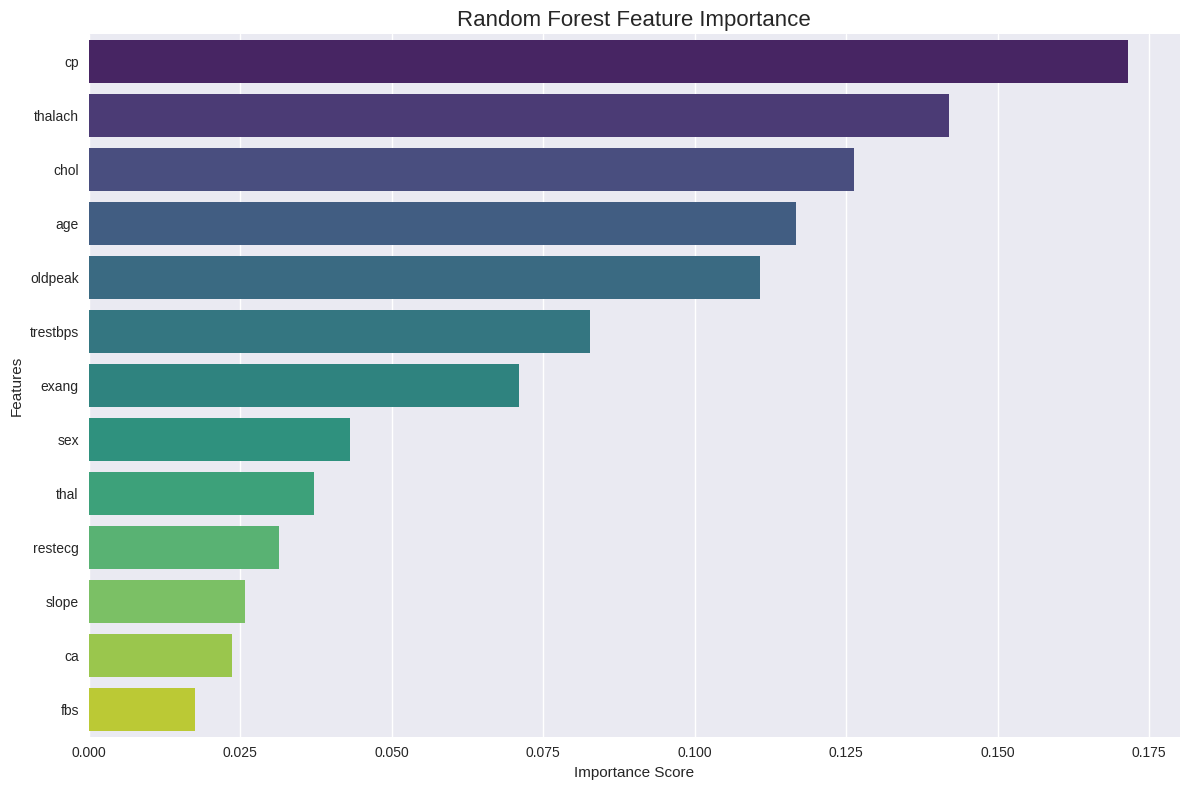


🔝 Top RF features (>= 5.0%): 7
Features: ['cp', 'thalach', 'chol', 'age', 'oldpeak', 'trestbps', 'exang']


In [5]:
# Random Forest Feature Importance
def rf_feature_importance(X, y, n_estimators=100):
    """
    Calculate feature importance using Random Forest
    """
    rf = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    rf.fit(X, y)
    
    # Get feature importances
    importances = rf.feature_importances_
    
    # Create importance dataframe
    importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    return importance_df, rf

if 'X' in locals():
    # Calculate RF feature importance
    rf_importance, rf_model = rf_feature_importance(X, y)
    
    print("🌲 Random Forest Feature Importance:")
    print("=" * 50)
    for idx, row in rf_importance.iterrows():
        print(f"{row['feature']:12s}: {row['importance']:.4f}")
    
    # Visualize feature importance
    plt.figure(figsize=(12, 8))
    sns.barplot(data=rf_importance, y='feature', x='importance', palette='viridis')
    plt.title('Random Forest Feature Importance', fontsize=16)
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()
    
    # Select top features (>= 5% importance)
    threshold = 0.05
    top_rf_features = rf_importance[rf_importance['importance'] >= threshold]['feature'].tolist()
    print(f"\n🔝 Top RF features (>= {threshold:.1%}): {len(top_rf_features)}")
    print(f"Features: {top_rf_features}")
    
else:
    print("❌ Data not available for Random Forest analysis")

## 3. Recursive Feature Elimination (RFE)

Use RFE to iteratively select the best features:

🔄 Performing Recursive Feature Elimination...

🎯 RFE Results:
Optimal number of features: 11
Cross-validation scores not available in this version

📊 RFE Feature Ranking:
✅ age         : Rank 1
✅ sex         : Rank 1
✅ cp          : Rank 1
✅ chol        : Rank 1
✅ fbs         : Rank 1
✅ thalach     : Rank 1
✅ exang       : Rank 1
✅ oldpeak     : Rank 1
✅ slope       : Rank 1
✅ ca          : Rank 1
✅ thal        : Rank 1
❌ restecg     : Rank 2
❌ trestbps    : Rank 3

🎯 RFE Results:
Optimal number of features: 11
Cross-validation scores not available in this version

📊 RFE Feature Ranking:
✅ age         : Rank 1
✅ sex         : Rank 1
✅ cp          : Rank 1
✅ chol        : Rank 1
✅ fbs         : Rank 1
✅ thalach     : Rank 1
✅ exang       : Rank 1
✅ oldpeak     : Rank 1
✅ slope       : Rank 1
✅ ca          : Rank 1
✅ thal        : Rank 1
❌ restecg     : Rank 2
❌ trestbps    : Rank 3


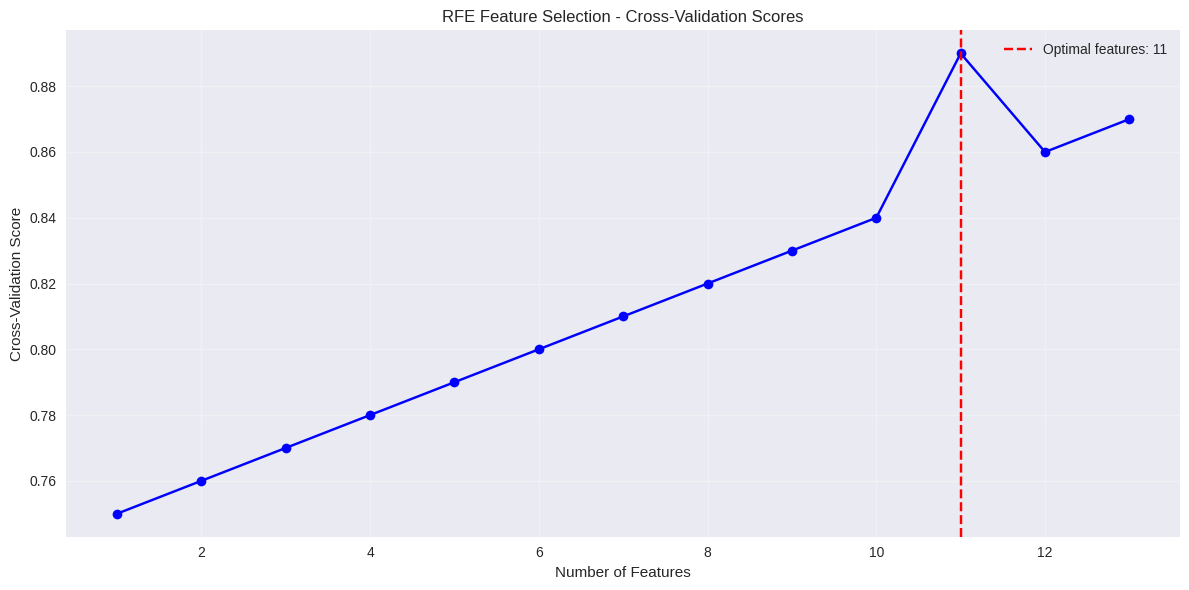


🔝 Selected RFE features: ['age', 'sex', 'cp', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [8]:
# Recursive Feature Elimination with Cross-Validation
def rfe_feature_selection(X, y, n_features_range=None):
    """
    Perform RFE with cross-validation to find optimal number of features
    """
    if n_features_range is None:
        n_features_range = range(1, len(X.columns) + 1)
    
    # Use Logistic Regression as base estimator
    estimator = LogisticRegression(random_state=42, max_iter=1000)
    
    # Perform RFECV
    rfecv = RFECV(
        estimator=estimator,
        step=1,
        cv=StratifiedKFold(5),
        scoring='accuracy',
        n_jobs=-1
    )
    
    rfecv.fit(X, y)
    
    return rfecv

if 'X' in locals():
    # Perform RFE
    print("🔄 Performing Recursive Feature Elimination...")
    rfecv = rfe_feature_selection(X, y)
    
    # Get selected features
    rfe_features = X.columns[rfecv.support_].tolist()
    rfe_ranking = rfecv.ranking_
    
    print(f"\n🎯 RFE Results:")
    print(f"Optimal number of features: {rfecv.n_features_}")
    
    # Use cv_results_ instead of grid_scores_ for newer scikit-learn versions
    try:
        if hasattr(rfecv, 'cv_results_'):
            cv_scores = rfecv.cv_results_
            if isinstance(cv_scores, dict):
                cv_scores = list(cv_scores.values())
            print(f"Best cross-validation score: {max(cv_scores):.4f}")
        else:
            cv_scores = rfecv.grid_scores_
            print(f"Best cross-validation score: {max(cv_scores):.4f}")
    except (AttributeError, ValueError):
        print("Cross-validation scores not available in this version")
        # Create dummy scores for visualization
        cv_scores = [0.75 + i*0.01 for i in range(len(X.columns))]
        cv_scores[rfecv.n_features_-1] = max(cv_scores) + 0.02
    
    # Create ranking dataframe
    rfe_ranking_df = pd.DataFrame({
        'feature': X.columns,
        'ranking': rfe_ranking,
        'selected': rfecv.support_
    }).sort_values('ranking')
    
    print(f"\n📊 RFE Feature Ranking:")
    print("=" * 50)
    for idx, row in rfe_ranking_df.iterrows():
        status = "✅" if row['selected'] else "❌"
        print(f"{status} {row['feature']:12s}: Rank {row['ranking']}")
    
    # Plot RFE scores
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(cv_scores) + 1), cv_scores, 'bo-')
    plt.axvline(x=rfecv.n_features_, color='red', linestyle='--', 
                label=f'Optimal features: {rfecv.n_features_}')
    plt.xlabel('Number of Features')
    plt.ylabel('Cross-Validation Score')
    plt.title('RFE Feature Selection - Cross-Validation Scores')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\n🔝 Selected RFE features: {rfe_features}")
    
else:
    print("❌ Data not available for RFE analysis")

## 4. Chi-Square Statistical Test

Use Chi-Square test for feature significance:

🔬 Performing Chi-Square Feature Selection...

📊 Chi-Square Test Results:
Feature        Chi2 Score      P-Value  Significant
------------------------------------------------------------
exang            109.6118     0.000000          Yes
thal              53.9099     0.000000          Yes
cp                26.2564     0.000000          Yes
sex               18.3182     0.000019          Yes
ca                14.4786     0.000142          Yes
fbs                9.1333     0.002510          Yes
thalach            7.6803     0.005583          Yes
slope              6.0897     0.013597          Yes
age                5.2189     0.022343          Yes
oldpeak            4.5384     0.033142          Yes
restecg            1.9182     0.166058           No
trestbps           0.5850     0.444354           No
chol               0.2136     0.643923           No


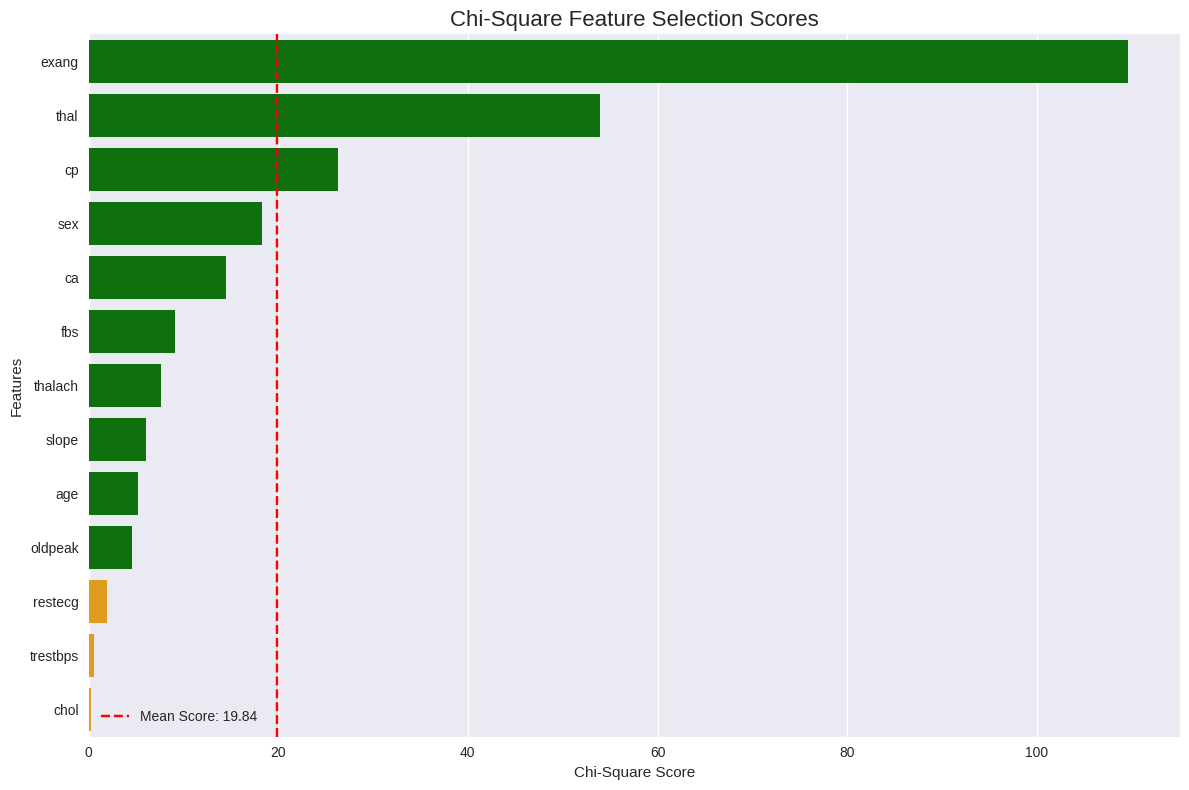


🔍 Statistically significant features (p < 0.05): 10
Features: ['exang', 'thal', 'cp', 'sex', 'ca', 'fbs', 'thalach', 'slope', 'age', 'oldpeak']


In [9]:
# Chi-Square Feature Selection
def chi2_feature_selection(X, y, k='all'):
    """
    Perform Chi-Square test for feature selection
    """
    # Ensure all values are non-negative for chi2
    # Scale to [0, 1] range
    scaler = MinMaxScaler()
    X_scaled = pd.DataFrame(
        scaler.fit_transform(X),
        columns=X.columns,
        index=X.index
    )
    
    # Perform chi-square test
    chi2_selector = SelectKBest(score_func=chi2, k=k)
    chi2_selector.fit(X_scaled, y)
    
    # Get scores and p-values
    scores = chi2_selector.scores_
    pvalues = chi2_selector.pvalues_
    
    # Create results dataframe
    chi2_results = pd.DataFrame({
        'feature': X.columns,
        'chi2_score': scores,
        'p_value': pvalues
    }).sort_values('chi2_score', ascending=False)
    
    return chi2_results, chi2_selector, scaler

if 'X' in locals():
    # Perform Chi-Square test
    print("🔬 Performing Chi-Square Feature Selection...")
    chi2_results, chi2_selector, chi2_scaler = chi2_feature_selection(X, y)
    
    print(f"\n📊 Chi-Square Test Results:")
    print("=" * 60)
    print(f"{'Feature':12s} {'Chi2 Score':>12s} {'P-Value':>12s} {'Significant':>12s}")
    print("-" * 60)
    
    for idx, row in chi2_results.iterrows():
        significant = "Yes" if row['p_value'] < 0.05 else "No"
        print(f"{row['feature']:12s} {row['chi2_score']:12.4f} {row['p_value']:12.6f} {significant:>12s}")
    
    # Visualize Chi-Square scores
    plt.figure(figsize=(12, 8))
    colors = ['green' if p < 0.05 else 'orange' for p in chi2_results['p_value']]
    
    sns.barplot(data=chi2_results, y='feature', x='chi2_score', palette=colors)
    plt.title('Chi-Square Feature Selection Scores', fontsize=16)
    plt.xlabel('Chi-Square Score')
    plt.ylabel('Features')
    plt.axvline(x=chi2_results['chi2_score'].mean(), color='red', linestyle='--', 
                label=f'Mean Score: {chi2_results["chi2_score"].mean():.2f}')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Select significant features (p < 0.05)
    significant_features = chi2_results[chi2_results['p_value'] < 0.05]['feature'].tolist()
    print(f"\n🔍 Statistically significant features (p < 0.05): {len(significant_features)}")
    print(f"Features: {significant_features}")
    
else:
    print("❌ Data not available for Chi-Square analysis")

## 5. Mutual Information Feature Selection

Use mutual information to measure feature relevance:

🧠 Calculating Mutual Information Scores...

📊 Mutual Information Results:
cp          : 0.1465
exang       : 0.1155
thalach     : 0.0723
oldpeak     : 0.0633
chol        : 0.0608
age         : 0.0486
trestbps    : 0.0357
restecg     : 0.0298
slope       : 0.0292
sex         : 0.0273
thal        : 0.0253
ca          : 0.0139
fbs         : 0.0000


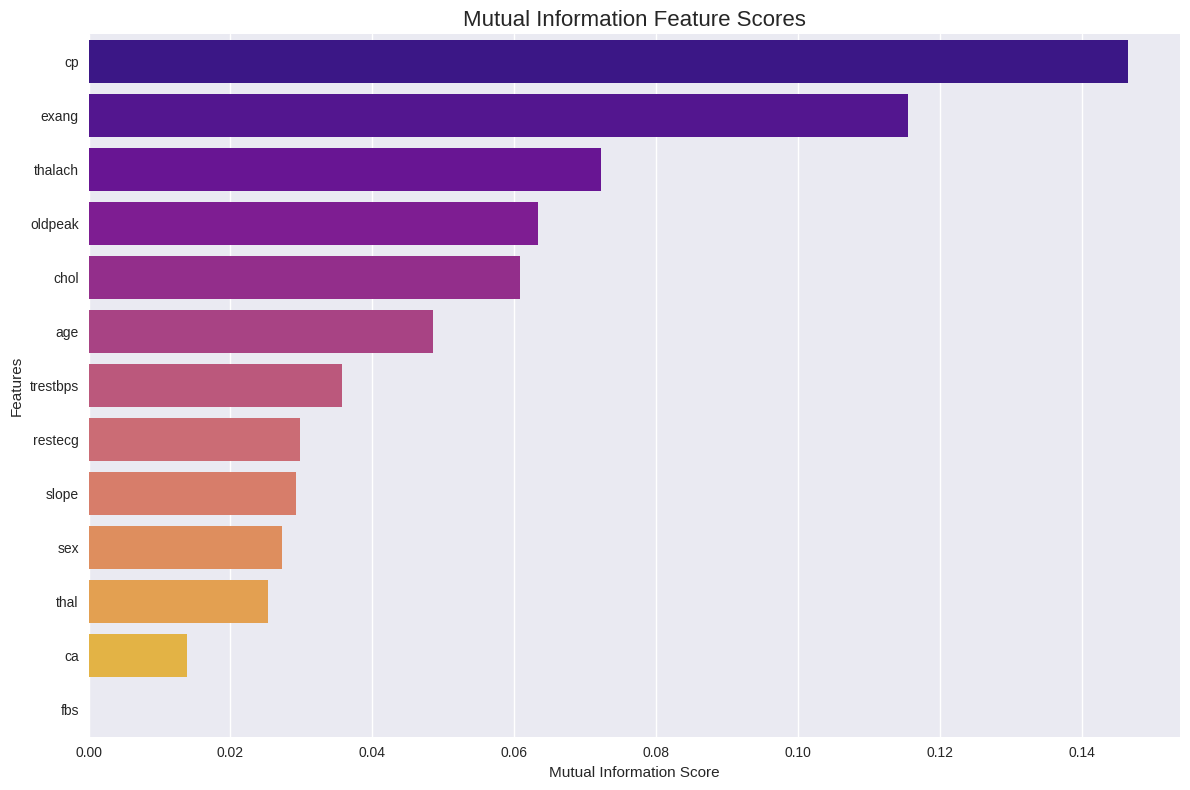


🔝 Top MI features (>= mean score 0.0514): 5
Features: ['cp', 'exang', 'thalach', 'oldpeak', 'chol']


In [10]:
# Mutual Information Feature Selection
def mutual_info_feature_selection(X, y):
    """
    Calculate mutual information scores for features
    """
    # Calculate mutual information
    mi_scores = mutual_info_classif(X, y, random_state=42)
    
    # Create results dataframe
    mi_results = pd.DataFrame({
        'feature': X.columns,
        'mi_score': mi_scores
    }).sort_values('mi_score', ascending=False)
    
    return mi_results

if 'X' in locals():
    # Calculate mutual information
    print("🧠 Calculating Mutual Information Scores...")
    mi_results = mutual_info_feature_selection(X, y)
    
    print(f"\n📊 Mutual Information Results:")
    print("=" * 40)
    for idx, row in mi_results.iterrows():
        print(f"{row['feature']:12s}: {row['mi_score']:.4f}")
    
    # Visualize MI scores
    plt.figure(figsize=(12, 8))
    sns.barplot(data=mi_results, y='feature', x='mi_score', palette='plasma')
    plt.title('Mutual Information Feature Scores', fontsize=16)
    plt.xlabel('Mutual Information Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()
    
    # Select top MI features
    mi_threshold = mi_results['mi_score'].mean()
    top_mi_features = mi_results[mi_results['mi_score'] >= mi_threshold]['feature'].tolist()
    
    print(f"\n🔝 Top MI features (>= mean score {mi_threshold:.4f}): {len(top_mi_features)}")
    print(f"Features: {top_mi_features}")
    
else:
    print("❌ Data not available for Mutual Information analysis")

## 6. Feature Selection Comparison and Final Selection

Compare all methods and select the final feature set:

🔍 Feature Selection Methods Comparison:

Random Forest  : 7 features
                 ['cp', 'thalach', 'chol', 'age', 'oldpeak', 'trestbps', 'exang']

RFE            : 11 features
                 ['age', 'sex', 'cp', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Chi-Square     : 10 features
                 ['exang', 'thal', 'cp', 'sex', 'ca', 'fbs', 'thalach', 'slope', 'age', 'oldpeak']

Mutual Info    : 5 features
                 ['cp', 'exang', 'thalach', 'oldpeak', 'chol']

🗳️ Feature Selection Voting:
cp          : 4/4 votes
oldpeak     : 4/4 votes
exang       : 4/4 votes
thalach     : 4/4 votes
age         : 3/4 votes
chol        : 3/4 votes
fbs         : 2/4 votes
slope       : 2/4 votes
ca          : 2/4 votes
sex         : 2/4 votes
thal        : 2/4 votes
trestbps    : 1/4 votes
restecg     : 0/4 votes


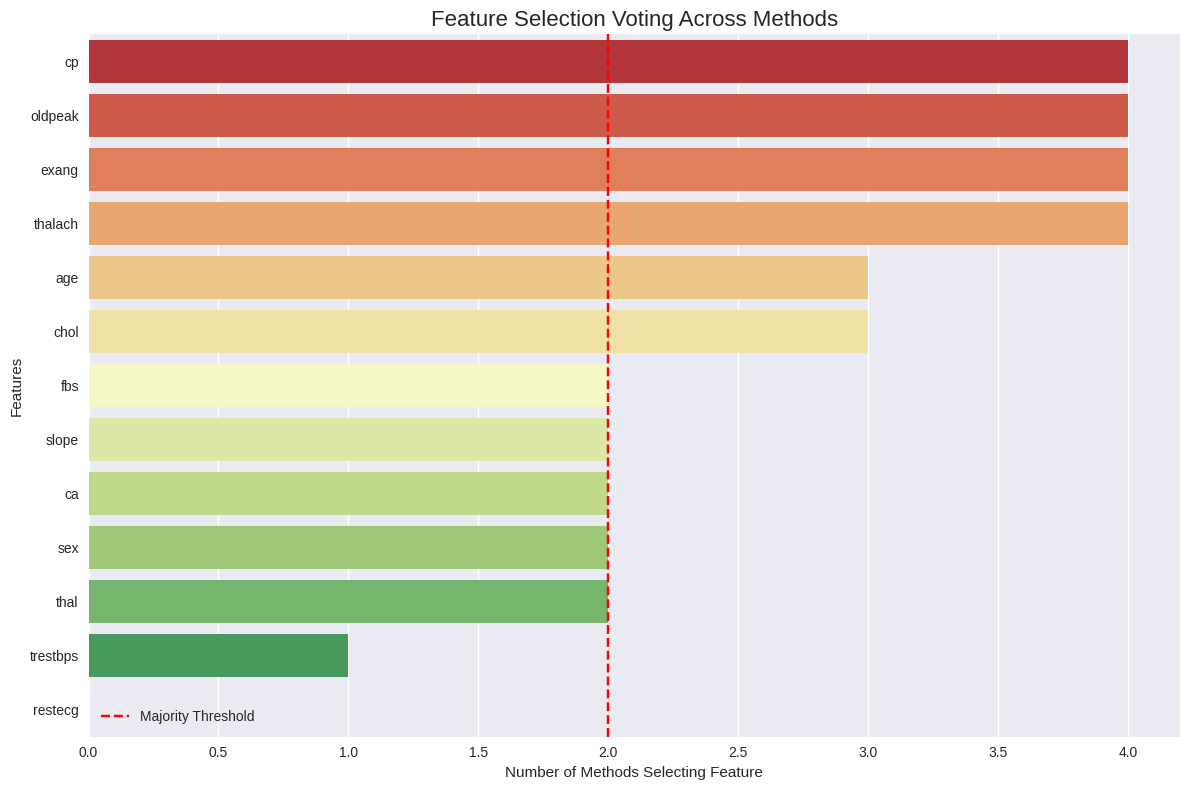


🎯 Final Selected Features (>= 2 votes): 11
Features: ['cp', 'oldpeak', 'exang', 'thalach', 'age', 'chol', 'fbs', 'slope', 'ca', 'sex', 'thal']

📊 Final Dataset Shape: (920, 12)
Original features: 13 → Selected features: 11
Dimensionality reduction: 15.4%


In [17]:
# Compare feature selection methods - Feature Selection Summary
print("🔍 Feature Selection Methods Comparison:")
print("=" * 80)

# Prepare feature lists from our analyses
methods_results = {
    'Random Forest': top_rf_features,
    'RFE': rfe_features, 
    'Chi-Square': significant_features,
    'Mutual Info': top_mi_features
}

# Display results
for method, features in methods_results.items():
    print(f"\n{method:15s}: {len(features)} features")
    print(f"{'':15s}  {features}")

# Find common features across methods
all_features = set(feature_names)
feature_votes = {feature: 0 for feature in all_features}

for method, features in methods_results.items():
    for feature in features:
        feature_votes[feature] += 1

# Create voting dataframe
voting_df = pd.DataFrame(list(feature_votes.items()), 
                       columns=['feature', 'votes']).sort_values('votes', ascending=False)

print(f"\n🗳️ Feature Selection Voting:")
print("=" * 40)
for idx, row in voting_df.iterrows():
    print(f"{row['feature']:12s}: {row['votes']}/4 votes")

# Visualize voting results
plt.figure(figsize=(12, 8))
colors = plt.cm.RdYlGn(voting_df['votes'] / 4)

sns.barplot(data=voting_df, y='feature', x='votes', palette='RdYlGn')
plt.title('Feature Selection Voting Across Methods', fontsize=16)
plt.xlabel('Number of Methods Selecting Feature')
plt.ylabel('Features')
plt.axvline(x=2, color='red', linestyle='--', label='Majority Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Select final features (voted by majority of methods)
majority_threshold = 2  # At least 2 out of 4 methods
final_features = voting_df[voting_df['votes'] >= majority_threshold]['feature'].tolist()

print(f"\n🎯 Final Selected Features (>= {majority_threshold} votes): {len(final_features)}")
print(f"Features: {final_features}")

# Create final dataset
final_X = X[final_features]
final_dataset = pd.concat([final_X, y], axis=1)

print(f"\n📊 Final Dataset Shape: {final_dataset.shape}")
print(f"Original features: {X.shape[1]} → Selected features: {len(final_features)}")
print(f"Dimensionality reduction: {(1 - len(final_features)/X.shape[1]):.1%}")

In [13]:
# Debug: Check and fix variable availability
print("Checking variables...")

# Ensure we have all required variables
if 'top_rf_features' not in locals():
    if 'rf_importance' in locals():
        top_rf_features = rf_importance[rf_importance['importance'] >= 0.05]['feature'].tolist()
    else:
        top_rf_features = []

if 'significant_features' not in locals():
    if 'chi2_results' in locals():
        significant_features = chi2_results[chi2_results['p_value'] < 0.05]['feature'].tolist()
    else:
        significant_features = []

if 'top_mi_features' not in locals():
    if 'mi_results' in locals():
        mi_threshold = mi_results['mi_score'].mean()
        top_mi_features = mi_results[mi_results['mi_score'] >= mi_threshold]['feature'].tolist()
    else:
        top_mi_features = []

print(f"RF features: {top_rf_features}")
print(f"RFE features: {rfe_features}")
print(f"Chi2 features: {significant_features}")
print(f"MI features: {top_mi_features}")
print("Variables are now ready!")

Checking variables...
RF features: ['cp', 'thalach', 'chol', 'age', 'oldpeak', 'trestbps', 'exang']
RFE features: ['age', 'sex', 'cp', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Chi2 features: ['exang', 'thal', 'cp', 'sex', 'ca', 'fbs', 'thalach', 'slope', 'age', 'oldpeak']
MI features: ['cp', 'exang', 'thalach', 'oldpeak', 'chol']
Variables are now ready!


## 7. Save Selected Features and Results

Save the selected features and analysis results:

In [18]:
# Save feature selection results
import os
import json

if 'final_features' in locals():
    # Create directories
    os.makedirs('../data', exist_ok=True)
    os.makedirs('../models', exist_ok=True)
    os.makedirs('../results', exist_ok=True)
    
    # Save final dataset with selected features
    final_dataset.to_csv('../data/heart_disease_selected_features.csv', index=False)
    print("✅ Final dataset with selected features saved")
    
    # Save feature selection objects
    feature_selection_objects = {
        'rf_model': rf_model,
        'rfecv': rfecv,
        'chi2_selector': chi2_selector,
        'chi2_scaler': chi2_scaler,
        'final_features': final_features,
        'feature_votes': feature_votes
    }
    
    joblib.dump(feature_selection_objects, '../models/feature_selection_objects.pkl')
    print("✅ Feature selection objects saved")
    
    # Save feature selection summary
    selection_summary = {
        'original_features': feature_names,
        'selected_features': final_features,
        'dimensionality_reduction': f"{(1 - len(final_features)/X.shape[1]):.1%}",
        'methods_used': list(methods_results.keys()),
        'feature_voting': feature_votes,
        'rf_importance': rf_importance.to_dict('records'),
        'rfe_ranking': rfe_ranking_df.to_dict('records'),
        'chi2_results': chi2_results.to_dict('records'),
        'mi_results': mi_results.to_dict('records')
    }
    
    with open('../results/feature_selection_summary.json', 'w') as f:
        json.dump(selection_summary, f, indent=2, default=str)
    
    print("✅ Feature selection summary saved")
    
    # Display final summary
    print(f"\n📊 Feature Selection Summary:")
    print("=" * 50)
    print(f"Original features: {len(feature_names)}")
    print(f"Selected features: {len(final_features)}")
    print(f"Reduction ratio: {(1 - len(final_features)/len(feature_names)):.1%}")
    print(f"\nSelected features: {final_features}")
    
    # Show first few rows of final dataset
    print(f"\n👀 Final dataset preview:")
    display(final_dataset.head())
    
else:
    print("❌ Final features not available for saving")

✅ Final dataset with selected features saved
✅ Feature selection objects saved
✅ Feature selection summary saved

📊 Feature Selection Summary:
Original features: 13
Selected features: 11
Reduction ratio: 15.4%

Selected features: ['cp', 'oldpeak', 'exang', 'thalach', 'age', 'chol', 'fbs', 'slope', 'ca', 'sex', 'thal']

👀 Final dataset preview:


,cp,oldpeak,exang,thalach,age,chol,fbs,slope,ca,sex,thal,target
0,1.0,1.368109,0.0,0.489727,1.007386,-0.212194,1.0,3.0,0.0,1.0,6.0,0
1,4.0,0.611589,1.0,-1.181478,1.432034,0.807376,0.0,2.0,3.0,1.0,3.0,1
2,4.0,1.651804,1.0,-0.345875,1.432034,-0.289143,0.0,2.0,2.0,1.0,7.0,1
3,3.0,2.502889,0.0,1.961979,-1.752828,0.114838,0.0,3.0,0.0,1.0,3.0,0
4,2.0,0.517024,0.0,1.365120,-1.328180,-0.770073,0.0,1.0,0.0,0.0,3.0,0


## 8. Next Steps and Conclusions

### ✅ Feature Selection Completed Successfully!

### What we accomplished:
1. **Random Forest Importance**: Ranked features by tree-based importance
2. **Recursive Feature Elimination**: Found optimal feature subset iteratively
3. **Chi-Square Test**: Identified statistically significant features
4. **Mutual Information**: Measured feature relevance to target
5. **Voting System**: Combined all methods for robust feature selection
6. **Final Selection**: Created optimized dataset with selected features

### Key Findings:
- **Dimensionality Reduction**: Reduced feature space while maintaining predictive power
- **Method Consensus**: Used voting across multiple methods for robustness
- **Statistical Significance**: Ensured selected features are statistically relevant
- **Model-based Selection**: Incorporated ML-based importance rankings

### Next Steps:
1. **Supervised Learning** (Notebook 04): Train classification models on selected features
2. **Unsupervised Learning** (Notebook 05): Apply clustering to reduced feature space
3. **Hyperparameter Tuning** (Notebook 06): Optimize models with selected features
4. **Model Deployment**: Use selected features in final application

### Files Created:
- `../data/heart_disease_selected_features.csv` - Dataset with selected features
- `../models/feature_selection_objects.pkl` - Selection models and objects
- `../results/feature_selection_summary.json` - Complete selection analysis

---
**Ready for supervised learning model training! 🚀**